# Homework 1 — End-to-End Reconstruction (Modulo II)
### Versione con Google Drive (caricamento veloce)

Ricostruzione di immagini Mayo sfocate da **motion blur** + rumore, con reti neurali
(SimpleCNN, ResCNN, UNet opzionale).

**IMPORTANTE — preparazione (una volta sola):**
1. Dal tuo browser vai su [drive.google.com](https://drive.google.com) e carica nella cartella
   `MyDrive/ComputationalImaging/` i due file: **`IPPy.zip`** e **`Mayo.zip`**.
   (Caricare da browser e' molto piu' veloce di `files.upload()` su Colab.)
2. Su Colab: `Runtime -> Cambia tipo di runtime -> T4 GPU -> Salva`.
3. Esegui le celle in ordine.

## 0. Verifica GPU

In [ ]:
import torch
import warnings, logging

warnings.filterwarnings("ignore")
logging.getLogger("py.warnings").setLevel(logging.ERROR)
print("CUDA disponibile:", torch.cuda.is_available())


CUDA disponibile: True
GPU: Tesla T4


## 1. Monta Google Drive e scompatta 

In [4]:
import glob
from google.colab import drive
drive.mount('/content/drive')
for target in ['Mayo.zip', 'IPPy.zip']:
    hits = glob.glob(f'/content/drive/MyDrive/**/{target}', recursive=True)
    print(target, '->', hits if hits else 'NON TROVATO')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mayo.zip -> ['/content/drive/MyDrive/Mayo.zip', '/content/drive/MyDrive/ComputationalImaging /Mayo.zip']
IPPy.zip -> ['/content/drive/MyDrive/IPPy.zip', '/content/drive/MyDrive/ComputationalImaging /IPPy.zip']


In [5]:
import zipfile, os, shutil, glob
import glob, os

drive_dir = '/content/drive/MyDrive'
# ==================================================================================

assert os.path.isdir(drive_dir), f"Cartella non trovata: {drive_dir}  (controlla il nome su Drive)"

for z in ['IPPy.zip', 'Mayo.zip']:
    src = os.path.join(drive_dir, z)
    assert os.path.isfile(src), "Manca {src} su Drive"
    print('Estrazione', z, '...')
    with zipfile.ZipFile(src) as zf:
        zf.extractall('/content/')
print('Fatto.')

# Sistema eventuali contenitori annidati di IPPy (es. IPPy-main/IPPy)
if not os.path.isdir('/content/IPPy'):
    for root, dirs, _ in os.walk('/content/'):
        if 'IPPy' in dirs and os.path.isfile(os.path.join(root, 'IPPy', '__init__.py')):
            shutil.move(os.path.join(root, 'IPPy'), '/content/IPPy'); break

# Trova automaticamente le cartelle train/ e test/ del Mayo (gestisce Mayo/train o Mayo/Mayo/train)
def find_split(split):
    hits = glob.glob(f'/content/**/{split}', recursive=True)
    hits = [h for h in hits if os.path.isdir(h) and glob.glob(f'{h}/*/*.png')]
    assert hits, f"Non trovo la cartella '{split}' con immagini .png dentro"
    return hits[0]

train_dir = find_split('train')
test_dir  = find_split('test')
print('train ->', train_dir)
print('test  ->', test_dir)
print('Esempio immagini train:', len(glob.glob(f'{train_dir}/*/*.png')))
print('Esempio immagini test :', len(glob.glob(f'{test_dir}/*/*.png')))

assert os.path.isdir('/content/IPPy'), "Manca /content/IPPy"
os.makedirs('/content/weights', exist_ok=True)

Estrazione IPPy.zip ...
Estrazione Mayo.zip ...
Fatto.
train -> /content/Mayo/train
test  -> /content/Mayo/test
Esempio immagini train: 3306
Esempio immagini test : 327


## 2. Import e device

In [6]:
import sys, math
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

sys.path.append('/content')
from IPPy import operators, utilities
from IPPy.utilities.metrics import PSNR, SSIM

weights_dir = Path('/content/weights')
# Forziamo cuda se disponibile (non affidiamoci solo a get_device)
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
print('Working device:', device)

Working device: cuda


 Parte 1 — Dataset, dataloader, operatore di degradazione

Il dataset contiene solo immagini pulite. La corruzione $y^\delta = Kx + e$ e'
generata al volo durante il training.

Training images: 3306 | Test images: 327


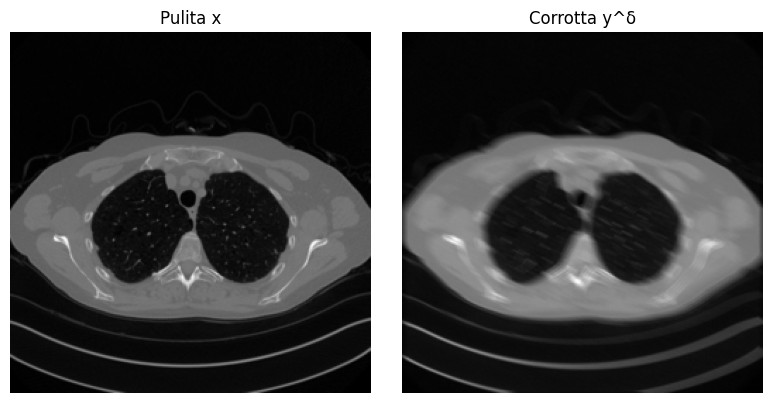

In [7]:
class MayoDataset(Dataset):
    def __init__(self, data_path, data_shape=256):
        super().__init__()
        self.fname_list = sorted(glob.glob(f'{data_path}/*/*.png'))
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((data_shape, data_shape)),
        ])
    def __len__(self):
        return len(self.fname_list)
    def __getitem__(self, idx):
        x = Image.open(self.fname_list[idx]).convert('L')
        return self.transform(x)

train_dataset = MayoDataset(train_dir, data_shape=256)
test_dataset  = MayoDataset(test_dir,  data_shape=256)
# num_workers=2 velocizza il caricamento; pin_memory aiuta col trasferimento su GPU
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
print('Training images:', len(train_dataset), '| Test images:', len(test_dataset))

K = operators.Blurring(img_shape=(256,256), kernel_type='motion', kernel_size=9, motion_angle=20)
noise_level = 0.01

# verifica pipeline
x0 = test_dataset[0].unsqueeze(0).to(device)
y0 = K(x0); y0 = y0 + utilities.gaussian_noise(y0, noise_level=noise_level)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(x0.cpu().squeeze(),cmap='gray'); plt.title('Pulita x'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(y0.cpu().squeeze(),cmap='gray'); plt.title('Corrotta y^δ'); plt.axis('off')
plt.tight_layout(); plt.show()

## 4. Parte 2 — Le reti (SimpleCNN, ResCNN)

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, n_filters=32, kernel_size=3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, n_filters, kernel_size, padding="same")
        self.conv2 = nn.Conv2d(n_filters, n_filters, kernel_size, padding="same")
        self.conv3 = nn.Conv2d(n_filters, out_ch, kernel_size, padding="same")
        self.relu = nn.ReLU()
    def forward(self, x):
        h = self.relu(self.conv1(x)); h = self.relu(self.conv2(h)); return self.conv3(h)

class ResCNN(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, n_filters=32, kernel_size=3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, n_filters, kernel_size, padding="same")
        self.conv2 = nn.Conv2d(n_filters, n_filters, kernel_size, padding="same")
        self.conv3 = nn.Conv2d(n_filters, out_ch, kernel_size, padding="same")
        self.relu = nn.ReLU(); self.tanh = nn.Tanh()
    def forward(self, x):
        h = self.relu(self.conv1(x)); h = self.relu(self.conv2(h))
        return self.tanh(self.conv3(h)) + x

for name, M in [('SimpleCNN', SimpleCNN()), ('ResCNN', ResCNN())]:
    print(f'{name}: {sum(p.numel() for p in M.parameters() if p.requires_grad)} parametri')

SimpleCNN: 9857 parametri
ResCNN: 9857 parametri


## 5. Parte 3 — Training

In [9]:
def train_model(model, weights_path, num_epochs=20, noise_level=0.01, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss(); history = []
    for epoch in range(num_epochs):
        model.train(); epoch_loss = 0.0
        bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', leave=False)
        for step, x_batch in enumerate(bar, start=1):
            x_batch = x_batch.to(device)                 # <-- batch su GPU
            with torch.no_grad():
                y_batch = K(x_batch)
                y_batch = y_batch + utilities.gaussian_noise(y_batch, noise_level=noise_level)
            prediction = model(y_batch)
            loss = loss_fn(prediction, x_batch)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            epoch_loss += loss.item()
            bar.set_postfix(avg_loss=f'{epoch_loss/step:.6f}')
        history.append(epoch_loss/len(train_loader))
        print(f'Epoch {epoch+1}: loss = {history[-1]:.6f}')
    torch.save(model.state_dict(), weights_path)
    print('Pesi salvati in:', weights_path)
    return history

In [10]:
torch.manual_seed(0)
cnn = SimpleCNN(n_filters=32)
hist_cnn = train_model(cnn, weights_dir/'CNN.pth', num_epochs=20, noise_level=noise_level)

Epoch 1/20:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 1: loss = 0.002458


Epoch 2/20:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 2: loss = 0.000899


Epoch 3/20:   0%|          | 0/414 [00:00<?, ?it/s]

...

Epoch 18: loss = 0.000392


Epoch 19/20:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 19: loss = 0.000390


Epoch 20/20:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 20: loss = 0.000385
Pesi salvati in: /content/weights/CNN.pth


In [11]:
torch.manual_seed(0)
rescnn = ResCNN(n_filters=32)
hist_res = train_model(rescnn, weights_dir/'ResCNN.pth', num_epochs=20, noise_level=noise_level)

Epoch 1/20:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 1: loss = 0.000985


Epoch 2/20:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 2: loss = 0.000572


Epoch 3/20:   0%|          | 0/414 [00:00<?, ?it/s]

...

Epoch 18: loss = 0.000348


Epoch 19/20:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 19: loss = 0.000343


Epoch 20/20:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 20: loss = 0.000340
Pesi salvati in: /content/weights/ResCNN.pth


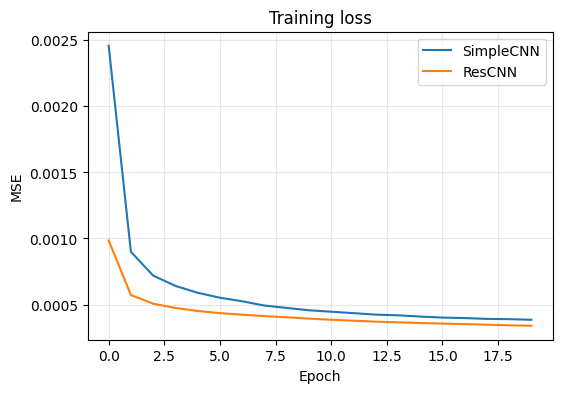

In [ ]:
# Ricarica i pesi salvati
cnn_eval = SimpleCNN(); cnn_eval.load_state_dict(torch.load(weights_dir/'CNN.pth', map_location=device, weights_only=True)); cnn_eval=cnn_eval.to(device).eval()
res_eval = ResCNN();    res_eval.load_state_dict(torch.load(weights_dir/'ResCNN.pth', map_location=device, weights_only=True)); res_eval=res_eval.to(device).eval()
plt.figure(figsize=(6,4))
plt.plot(hist_cnn,label='SimpleCNN'); plt.plot(hist_res,label='ResCNN')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.grid(alpha=0.3); plt.title('Training loss'); plt.show()

## 6. Parte 4 — Confronto visivo e quantitativo

Corrotta     | MSE=0.001447 | PSNR=28.40 dB | SSIM=0.8423
SimpleCNN    | MSE=0.000359 | PSNR=34.45 dB | SSIM=0.9243
ResCNN       | MSE=0.000321 | PSNR=34.94 dB | SSIM=0.9282


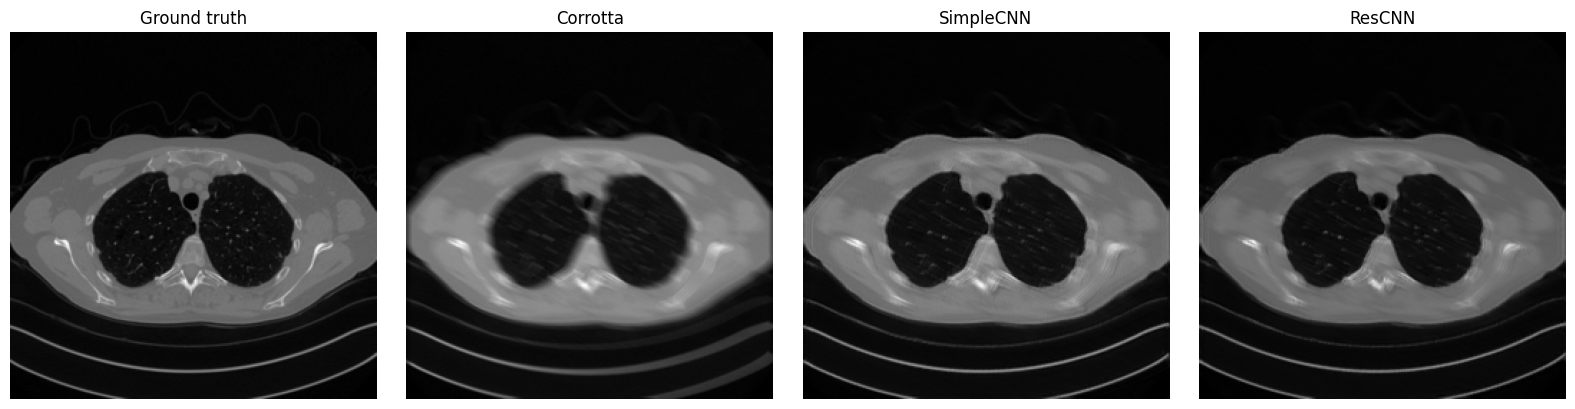

In [13]:
torch.manual_seed(123)
x_true = test_dataset[0].unsqueeze(0).to(device)
y_delta = K(x_true); y_delta = y_delta + utilities.gaussian_noise(y_delta, noise_level=noise_level)
with torch.no_grad():
    rec_cnn = cnn_eval(y_delta); rec_res = res_eval(y_delta)

def metrics_row(name, rec):
    mse = torch.mean((rec - x_true)**2).item()
    return f'{name:<12} | MSE={mse:.6f} | PSNR={PSNR(rec.clamp(0,1),x_true):.2f} dB | SSIM={SSIM(rec.clamp(0,1),x_true):.4f}'
print(metrics_row('Corrotta', y_delta)); print(metrics_row('SimpleCNN', rec_cnn)); print(metrics_row('ResCNN', rec_res))

imgs=[x_true,y_delta,rec_cnn,rec_res]; titles=['Ground truth','Corrotta','SimpleCNN','ResCNN']
plt.figure(figsize=(16,4))
for i,(im,t) in enumerate(zip(imgs,titles)):
    plt.subplot(1,4,i+1); plt.imshow(im.cpu().squeeze().clamp(0,1),cmap='gray'); plt.title(t); plt.axis('off')
plt.tight_layout(); plt.show()

## 7. (Opzionale) UNet

UNet parametri: 1925025


Epoch 1/10:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 1: loss = 0.001660


Epoch 2/10:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 2: loss = 0.000259


...

Epoch 8: loss = 0.000077


Epoch 9/10:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 9: loss = 0.000113


Epoch 10/10:   0%|          | 0/414 [00:00<?, ?it/s]

Epoch 10: loss = 0.000077
Pesi salvati in: /content/weights/UNet.pth
UNet         | MSE=0.000075 | PSNR=41.24 dB | SSIM=0.9744


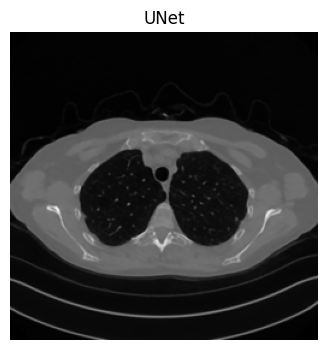

In [14]:
import torch.nn.functional as F
class DoubleConv(nn.Module):
    def __init__(s,i,o):
        super().__init__(); s.b=nn.Sequential(nn.Conv2d(i,o,3,padding=1),nn.ReLU(),nn.Conv2d(o,o,3,padding=1),nn.ReLU())
    def forward(s,x): return s.b(x)
class DownBlock(nn.Module):
    def __init__(s,i,o):
        super().__init__(); s.p=nn.MaxPool2d(2); s.b=DoubleConv(i,o)
    def forward(s,x): return s.b(s.p(x))
class UpBlock(nn.Module):
    def __init__(s,i,sk,o):
        super().__init__(); s.up=nn.ConvTranspose2d(i,o,2,stride=2); s.b=DoubleConv(o+sk,o)
    def forward(s,x,skip):
        x=s.up(x)
        if x.shape[-2:]!=skip.shape[-2:]: x=F.interpolate(x,size=skip.shape[-2:],mode='bilinear',align_corners=False)
        return s.b(torch.cat([skip,x],dim=1))
class SimpleUNet(nn.Module):
    def __init__(s,in_ch=1,out_ch=1,base=32):
        super().__init__()
        s.e1=DoubleConv(in_ch,base); s.e2=DownBlock(base,2*base); s.e3=DownBlock(2*base,4*base); s.bott=DownBlock(4*base,8*base)
        s.d3=UpBlock(8*base,4*base,4*base); s.d2=UpBlock(4*base,2*base,2*base); s.d1=UpBlock(2*base,base,base)
        s.out=nn.Conv2d(base,out_ch,1)
    def forward(s,x):
        a=s.e1(x); b=s.e2(a); c=s.e3(b); h=s.bott(c)
        h=s.d3(h,c); h=s.d2(h,b); h=s.d1(h,a); return s.out(h)

torch.manual_seed(0)
unet = SimpleUNet()
print('UNet parametri:', sum(p.numel() for p in unet.parameters() if p.requires_grad))
hist_unet = train_model(unet, weights_dir/'UNet.pth', num_epochs=10, noise_level=noise_level)
unet_eval = SimpleUNet(); unet_eval.load_state_dict(torch.load(weights_dir/'UNet.pth', map_location=device, weights_only=True)); unet_eval=unet_eval.to(device).eval()
with torch.no_grad(): rec_unet = unet_eval(y_delta)
print(metrics_row('UNet', rec_unet))
plt.figure(figsize=(5,4)); plt.imshow(rec_unet.cpu().squeeze().clamp(0,1),cmap='gray'); plt.title('UNet'); plt.axis('off'); plt.show()

## 8. (Consigliato) Copia i pesi su Drive per non perderli
Colab cancella `/content/` alla chiusura. Salva i pesi su Drive:

In [15]:
import shutil
dest = os.path.join(drive_dir, 'weights')
os.makedirs(dest, exist_ok=True)
for f in glob.glob('/content/weights/*.pth'):
    shutil.copy(f, dest)
print('Pesi copiati su Drive in:', dest)

Pesi copiati su Drive in: /content/drive/MyDrive/weights



**1. Which model performed better, and why?**
The **ResCNN** performed slightly better than the SimpleCNN (PSNR 34.94 vs 34.45 dB, SSIM 0.928 vs 0.924), and both improved the corrupted image by about 6 dB. The two networks have the same number of parameters (9857), so the gap does not come from capacity but from how they use it. The residual model only has to learn the *correction* to add to the corrupted input, which is an easier target than predicting the whole clean image from scratch, and this gives it a small but consistent advantage.

**2. Did the residual architecture help, and in what sense?**
Yes, in a modest but clear sense. Because the corrupted image is already close to the clean one, most of the output is "already there", so asking the network to predict only the residual (what must be changed) means it starts from a good initial guess and focuses its capacity on the differences, mainly deblurring and noise removal. With the same parameter budget this made training reach a lower loss and produced better PSNR and SSIM. The improvement is small here because the task is relatively easy at this noise level, but the residual formulation helps and tends to help more as the problem gets harder.

**3. How did the noise level affect training and reconstruction quality?**
The added noise is what makes the problem a genuine inverse problem: without it, deblurring alone would be almost trivial. Higher noise makes the mapping harder to learn and lowers the achievable reconstruction quality, because the network must both invert the blur and suppress noise without erasing real structures. It also makes results less consistent across images. At the moderate level we used, both models still recovered most of the structure (SSIM above 0.92), but we would expect the metrics to drop and the variance to grow if the noise were increased.

**4. Why generate the corruption through a known operator K instead of a generic image-to-image task?**
Because using a known forward operator y = K x + e ties the problem to the actual physics of the degradation. It lets us simulate realistic, controlled measurements and keeps the experiment honest, since training and test data are corrupted in the same well defined way. A generic image-to-image setup would ignore this structure and just learn a statistical mapping, which can look right but is not grounded in the measurement model and generalises poorly when the degradation changes. Knowing K is also what would later allow data-consistency checks between the reconstruction and the measurement.

**5. Why be cautious when evaluating pure end-to-end methods only through visual quality?**
End to end networks are trained to minimise a pixel loss and tend to produce smooth, visually pleasing outputs, but a clean looking image is not necessarily a faithful one. These models do not explicitly enforce consistency with the measurement, so they can smooth away or invent fine details while still looking good to the eye. This is why we report quantitative metrics such as PSNR and SSIM and compare against the ground truth, rather than trusting appearance alone, which matters even more in medical imaging where a missed or hallucinated detail has real consequences.

**6. UNet extension.**
We did not implement the optional UNet extension, so we limit our comparison to SimpleCNN and ResCNN. We would expect a UNet to outperform both, because its encoder decoder structure with skip connections captures context at multiple scales and recovers fine detail better than a shallow convolutional stack, at the cost of more parameters and longer training.

Se poi aggiungi la UNet, dimmi i suoi numeri e ti riscrivo la 6 (e aggiorno la 1 se vince lei). Vuoi che te le incolli già nella cella markdown finale del notebook HW1?